In [113]:
import pandas as pd

In [114]:
df = pd.read_csv('dataset.csv')


In [115]:
df.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Infill Pattern', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)'],
      dtype='object')

In [116]:
import pandas as pd
import numpy as np

def augment_data_vectorized(df, n_synthetic=10):
    """
    Expands the dataset by generating synthetic samples using Gaussian noise.
    
    Args:
        df: The original DataFrame.
        n_synthetic: Number of synthetic points to generate per original row.
    """
    # 1. Repeat each row n_synthetic times
    df_aug = df.loc[df.index.repeat(n_synthetic)].reset_index(drop=True)
    
    # 2. Generate Gaussian noise: Mean = 0, SD = 1
    # We multiply this by the actual SD from the table to scale the noise
    noise = np.random.normal(size=len(df_aug))
    
    # 3. Apply the noise: New Value = Mean + (Noise * SD)
    df_aug['Tensile Stress (Augmented)'] = (
        df_aug['Mean Tensile Stress (MPa)'] + 
        (noise * df_aug['Tensile Stress SD (MPa)'])
    ).round(3)
    
    # 4. Shuffle the dataset so the model doesn't learn the order of experiments
    return df_aug.sample(frac=1).reset_index(drop=True)

# Execute the augmentation
# If you have 33 rows, this will result in 330 rows
augmented_df = augment_data_vectorized(df, n_synthetic=10)

# Display a preview
print(f"Dataset expanded from {len(df)} to {len(augmented_df)} rows.")
print(augmented_df[['Infill Pattern', 'Mean Tensile Stress (MPa)', 'Tensile Stress (Augmented)']].head())

Dataset expanded from 33 to 330 rows.
  Infill Pattern  Mean Tensile Stress (MPa)  Tensile Stress (Augmented)
0  Triangle-Hexa                      11.08                      10.901
1           Grid                      13.87                      14.011
2           Grid                      13.87                      13.477
3           Grid                      14.26                      14.460
4           Grid                      17.44                      17.215


In [117]:
augmented_df.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Infill Pattern', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)'],
      dtype='object')

In [118]:
augmented_df

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Infill Pattern,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,23,5,45.87,225.86,Triangle-Hexa,11.08,0.29,10.901
1,9,19,60.00,240.00,Grid,13.87,0.44,14.011
2,9,19,60.00,240.00,Grid,13.87,0.44,13.477
3,10,31,60.00,240.00,Grid,14.26,0.51,14.460
4,6,24,80.00,240.00,Grid,17.44,0.82,17.215
...,...,...,...,...,...,...,...,...
325,12,7,45.87,225.86,Triangle,9.70,0.28,9.595
326,19,27,60.00,260.00,Triangle,13.90,0.37,14.078
327,23,5,45.87,225.86,Triangle-Hexa,11.08,0.29,11.088
328,1,14,45.86,225.86,Grid,8.42,0.31,8.246


In [119]:
# one-hot encode the 'Infill Pattern' column
df_encoded = pd.get_dummies(augmented_df, columns=['Infill Pattern'])
df_encoded['Infill Pattern_Grid'] = df_encoded['Infill Pattern_Grid'].astype(int)
df_encoded['Infill Pattern_Triangle'] = df_encoded['Infill Pattern_Triangle'].astype(int)
df_encoded['Infill Pattern_Triangle-Hexa'] = df_encoded['Infill Pattern_Triangle-Hexa'].astype(int)



In [120]:
print (df_encoded.describe())

       Test Sample  Experimental Run  Infill Density (%)  \
count   330.000000        330.000000          330.000000   
mean     17.000000         17.000000           60.000606   
std       9.536365          9.536365           12.077145   
min       1.000000          1.000000           40.000000   
25%       9.000000          9.000000           45.870000   
50%      17.000000         17.000000           60.000000   
75%      25.000000         25.000000           74.140000   
max      33.000000         33.000000           80.000000   

       Nozzle Temperature (C)  Mean Tensile Stress (MPa)  \
count              330.000000                 330.000000   
mean               240.000000                  13.461818   
std                 12.077857                   2.692707   
min                220.000000                   8.420000   
25%                225.860000                  11.080000   
50%                240.000000                  13.670000   
75%                254.140000          

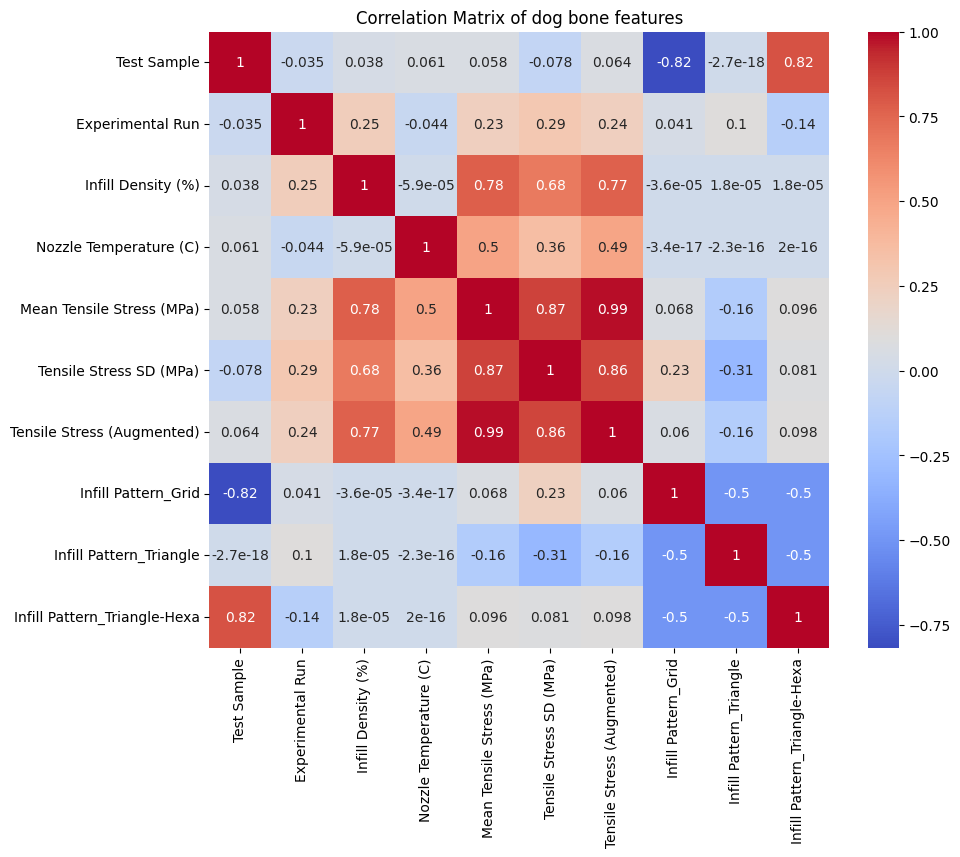

In [121]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of dog bone features')
plt.show()

In [122]:
df_encoded.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)',
       'Infill Pattern_Grid', 'Infill Pattern_Triangle',
       'Infill Pattern_Triangle-Hexa'],
      dtype='object')

## Effective Area ($A_{eff}$)

In [123]:
# Create a mapping for the Geometry Factor
# Note: Since your data is one-hot encoded, we multiply by the column indicator
df_encoded['Effective Load-Bearing Area (Aeff)'] = df_encoded['Infill Density (%)'] * (
    (df_encoded['Infill Pattern_Triangle-Hexa'] * 1.0) +
    (df_encoded['Infill Pattern_Triangle'] * 0.85) +
    (df_encoded['Infill Pattern_Grid'] * 0.70)
)

In [124]:
df_encoded

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff)
0,23,5,45.87,225.86,11.08,0.29,10.901,0,0,1,45.8700
1,9,19,60.00,240.00,13.87,0.44,14.011,1,0,0,42.0000
2,9,19,60.00,240.00,13.87,0.44,13.477,1,0,0,42.0000
3,10,31,60.00,240.00,14.26,0.51,14.460,1,0,0,42.0000
4,6,24,80.00,240.00,17.44,0.82,17.215,1,0,0,56.0000
...,...,...,...,...,...,...,...,...,...,...,...
325,12,7,45.87,225.86,9.70,0.28,9.595,0,1,0,38.9895
326,19,27,60.00,260.00,13.90,0.37,14.078,0,1,0,51.0000
327,23,5,45.87,225.86,11.08,0.29,11.088,0,0,1,45.8700
328,1,14,45.86,225.86,8.42,0.31,8.246,1,0,0,32.1020


## polymer difusin rate

In [125]:
# 1. Define Constants
Ea = 68000  # Activation Energy for PA6 (J/mol)
R = 8.314    # Gas Constant
T_kelvin = df_encoded['Nozzle Temperature (C)'] + 273.15

# 2. Calculate Polymer Diffusion Rate
# We can set D0 = 1 for relative comparison
df_encoded['Diffusion Rate'] = np.exp(-Ea / (R * T_kelvin))

# 3. Normalize it so it stays on a 0-1 scale like your other features
df_encoded['Diffusion_Rate_Normalized'] = (df_encoded['Diffusion Rate'] - df_encoded['Diffusion Rate'].min()) / \
                                          (df_encoded['Diffusion Rate'].max() - df_encoded['Diffusion Rate'].min())

In [126]:
df_encoded[['Mean Tensile Stress (MPa)','Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)']]

,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,11.08,0.29,10.901
1,13.87,0.44,14.011
2,13.87,0.44,13.477
3,14.26,0.51,14.460
4,17.44,0.82,17.215
...,...,...,...
325,9.70,0.28,9.595
326,13.90,0.37,14.078
327,11.08,0.29,11.088
328,8.42,0.31,8.246


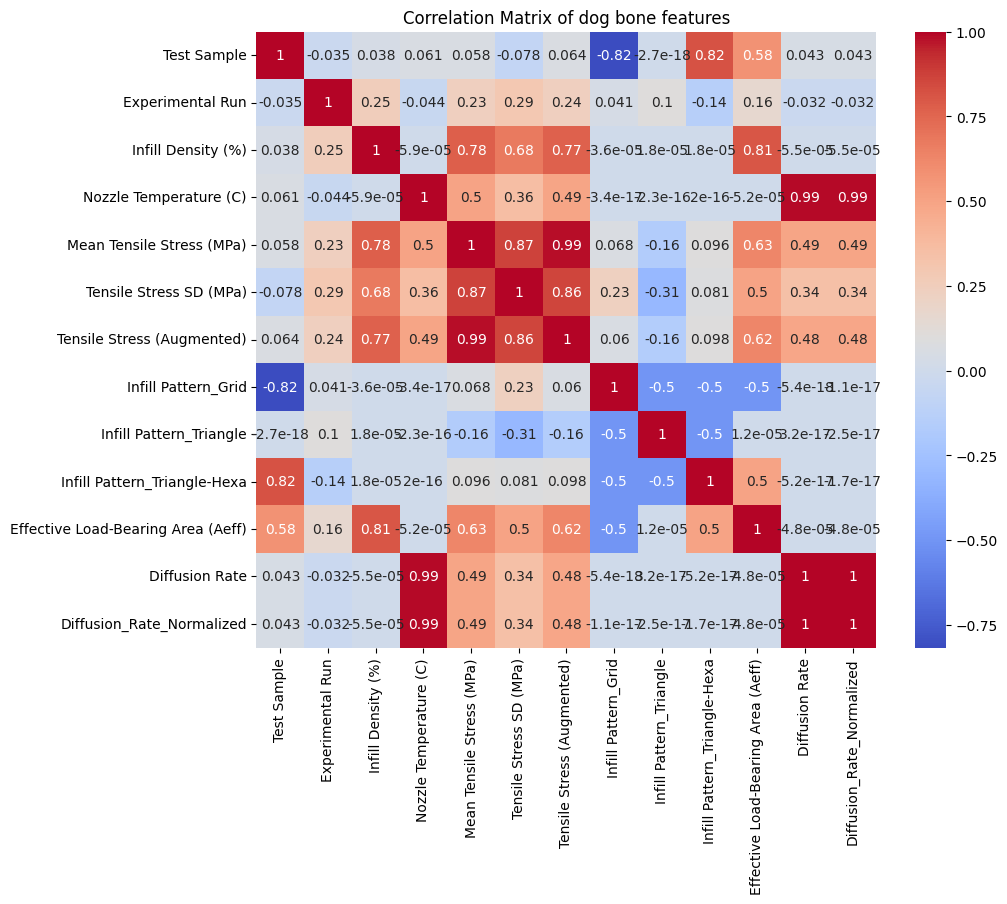

In [127]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of dog bone features')
plt.show()

In [128]:
df_encoded

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff),Diffusion Rate,Diffusion_Rate_Normalized
0,23,5,45.87,225.86,11.08,0.29,10.901,0,0,1,45.8700,7.616198e-08,0.087035
1,9,19,60.00,240.00,13.87,0.44,14.011,1,0,0,42.0000,1.196421e-07,0.367799
2,9,19,60.00,240.00,13.87,0.44,13.477,1,0,0,42.0000,1.196421e-07,0.367799
3,10,31,60.00,240.00,14.26,0.51,14.460,1,0,0,42.0000,1.196421e-07,0.367799
4,6,24,80.00,240.00,17.44,0.82,17.215,1,0,0,56.0000,1.196421e-07,0.367799
...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,12,7,45.87,225.86,9.70,0.28,9.595,0,1,0,38.9895,7.616198e-08,0.087035
326,19,27,60.00,260.00,13.90,0.37,14.078,0,1,0,51.0000,2.175468e-07,1.000000
327,23,5,45.87,225.86,11.08,0.29,11.088,0,0,1,45.8700,7.616198e-08,0.087035
328,1,14,45.86,225.86,8.42,0.31,8.246,1,0,0,32.1020,7.616198e-08,0.087035


In [ ]:
# Physics-Augmented Features

FEATURES_PHYSICS = [
    'Test Sample', 
    'Experimental Run', 
    'Infill Density (%)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa', 
    'Effective Load-Bearing Area (Aeff)', 
    'Diffusion_Rate_Normalized'
]


# Baseline Features (Standard Engineering)
FEATURES_BASE = [
    'Test Sample', 
    'Experimental Run', 
    'Infill Density (%)', 
    'Nozzle Temperature (C)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa'
]

# Defining the target
target_augmented = 'Tensile Stress (Augmented)'
target_validation = 'Mean Tensile Stress (MPa)'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (264, 7)
Shape of X_test: (66, 7)
Shape of y_train: (264,)
Shape of y_test: (66,)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

rf_r2_base  = r2_score(y_test, y_pred)
rf_mse_base = mean_squared_error(y_test, y_pred)
rf_rmse_base = np.sqrt(rf_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Random Forest Prediction (Test) for BaseLine Features ===")
print(f"R²          : {rf_r2_base:.4f}")
print(f"RMSE        : {rf_rmse_base:.3f} °C")
print(f"MSE         : {rf_mse_base:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 MPa : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 MPa : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 MPa : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 MPa : {rf_acc_30 * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2 = cross_val_score(rf_base, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': rf_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))